# W05A · 설명편차와 R²

2026-09-28 | 회귀분석의 이해 | **R 커널**

런타임 → 모두 실행으로 처음부터 실행합니다. 패키지 설치와 API 키는 필요 없습니다. 공통 R 소스만 고정 버전에서 내려받으며 이후 해시가 같은 캐시를 사용합니다. 연결이 끊기면 런타임을 다시 연결하고 위에서부터 실행하세요. 출력이 남아 있다고 현재 R 객체가 살아 있는 것은 아닙니다.

[전체 온라인 R](https://lunalab-ai.github.io/regre/w05a.html) · [공통 코드 입력·출력/정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-api.md) · [웹 앱](https://lunalab-ai.github.io/regre/apps/w05a/edit/index.html)

## 그림과 수식의 연결

$$y_i-\bar y=(\hat y_i-\bar y)+(y_i-\hat y_i),\qquad R^2=1-\frac{\mathrm{SSE}}{\mathrm{SST}}.$$

절편 포함 최소제곱, 같은 표본을 기준으로 읽습니다. p는 설명변수 수입니다.

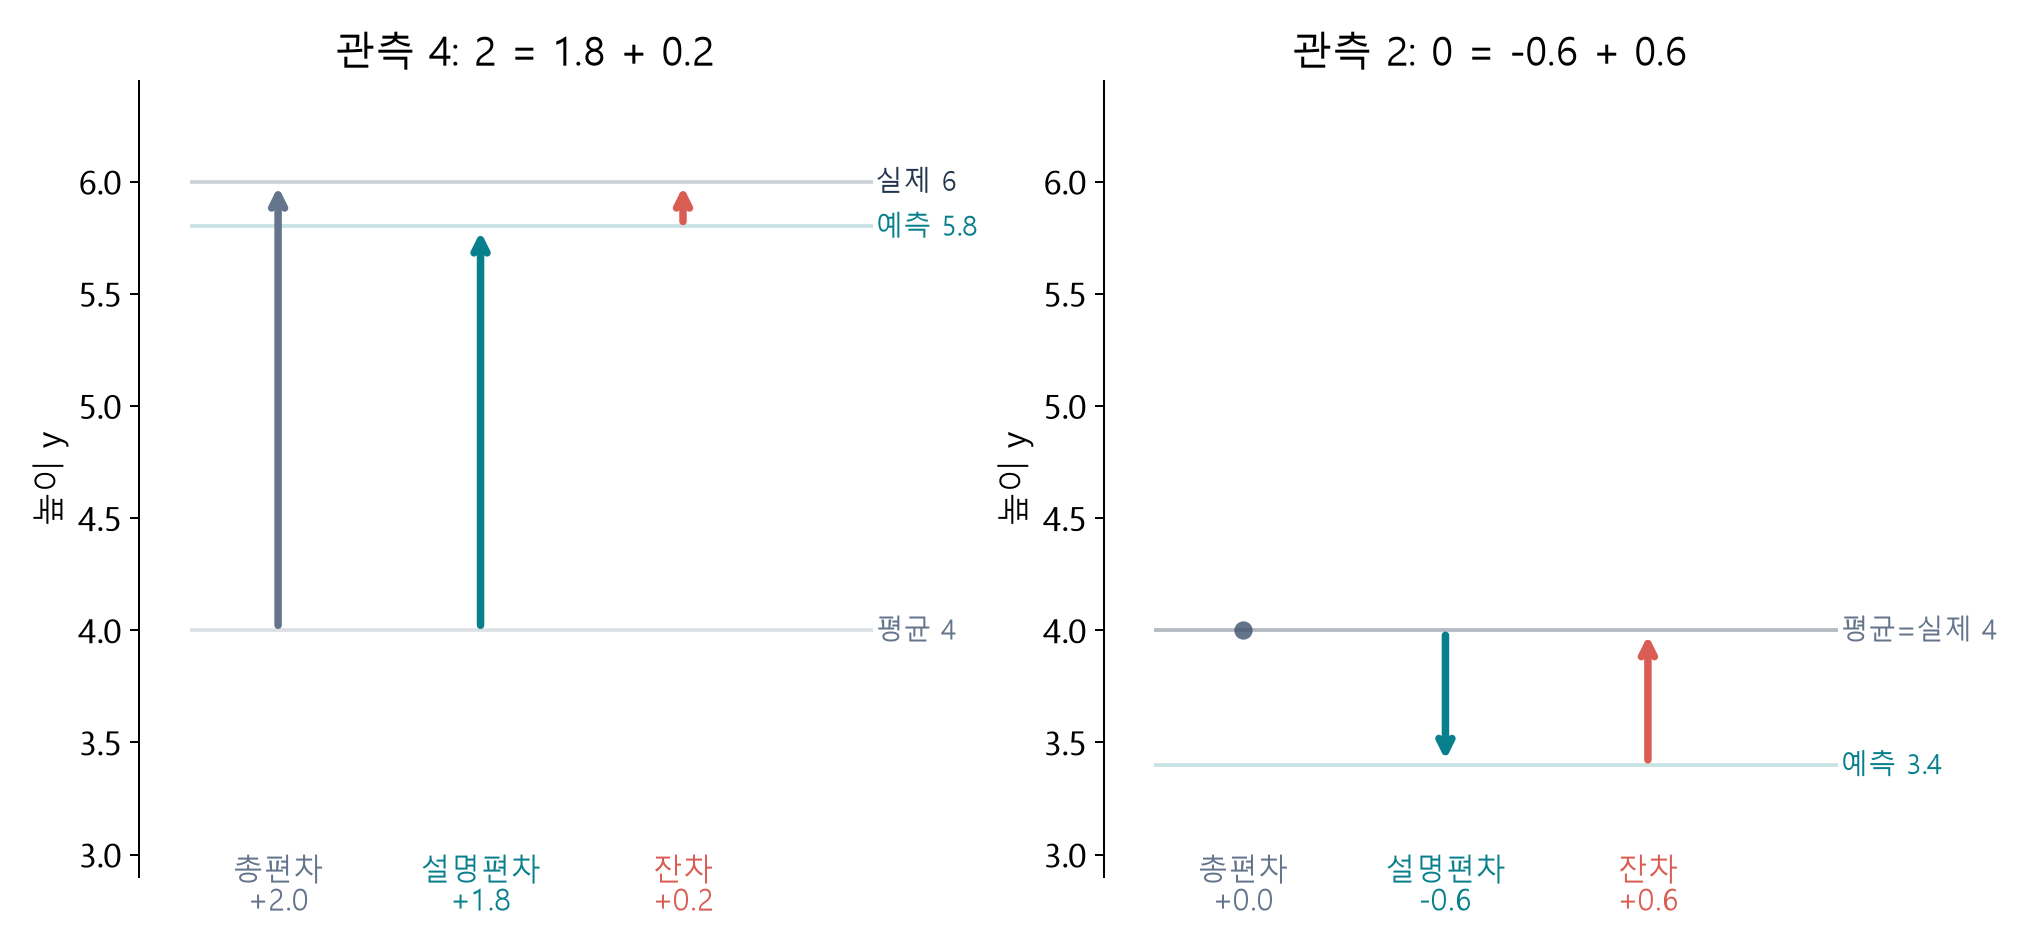

평균에서 예측으로 이동한 설명편차와 예측에서 실제로 이동한 잔차. 본 수업의 실제 계산으로 만든 그림입니다. [원본](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/course/notion/w05a/assets/r03-signed-deviations.png)

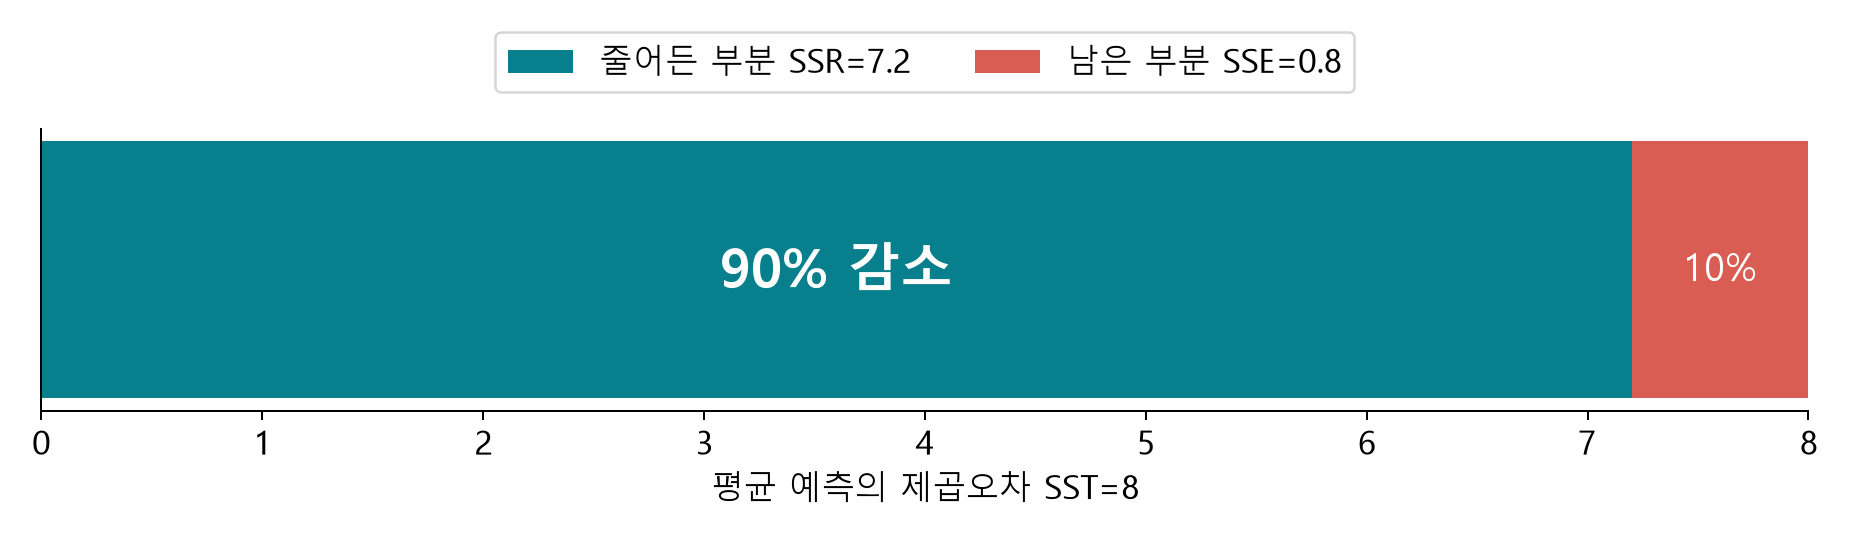

평균 예측의 제곱오차8 중7.2가 감소한 비율90%. 본 수업의 실제 계산으로 만든 그림입니다. [원본](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/course/notion/w05a/assets/r05-r2.png)

## 1. 준비와 실행 순서

오늘은 **예측 → 실행 → 설명** 순서로 읽습니다. 설치 없는 온라인 R 또는 R 커널 Colab 중 하나만 사용해도 됩니다. 아래 코드는 R입니다. Colab에서 Python 런타임으로 바꾸지 마세요. 처음부터 실행한 뒤 연습 셀을 수정하고, 결과가 왜 바뀌었는지 말로 설명합니다.

다운로드한 R/QMD는 `data` 폴더를 함께 두세요. 웹에서는 Run Code, Colab에서는 셀 왼쪽 실행 버튼을 누릅니다. 아래 공통 코드의 입력·출력·실제 정의 줄은 [API 안내](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-api.md)에 연결되어 있습니다. 학생 연습은 주석으로 남겨 기본 실행을 막지 않습니다. 주석 표시 `#`를 지우고 직접 코드를 완성하세요.

In [ ]:
# 고정 버전 공통 코드: 공개 소스와 동일한 MD5인지 확인합니다.
source_url <- "https://raw.githubusercontent.com/lunalab-ai/regre/2026-fall-w05a/src/mlr-tools.R"
expected_md5 <- "4a5ce6e20ace2451c513cef7a8bcfe2f"
local_candidates <- c("src/mlr-tools.R", "../../src/mlr-tools.R")
existing <- local_candidates[file.exists(local_candidates)]
if (length(existing)) {
  helper_path <- existing[1]
  helper_origin <- "동봉 소스"
} else {
  cache_dir <- file.path(path.expand("~"), ".cache", "regre", "2026-fall-w05a")
  dir.create(cache_dir, recursive=TRUE, showWarnings=FALSE)
  helper_path <- file.path(cache_dir,"mlr-tools.R")
  helper_origin <- if (file.exists(helper_path)) "검증된 캐시" else "고정 버전 최초 다운로드"
  if (!file.exists(helper_path)) download.file(source_url, helper_path, mode="wb", quiet=FALSE)
}
if (unname(tools::md5sum(helper_path)) != expected_md5)
  stop("공통 코드 해시가 다릅니다. 버전과 파일을 확인하세요. 실패를 무시하지 마세요.")
source(helper_path)
cat(helper_origin," | R ",as.character(getRversion()),"
",sep="")

## 2. 평균만 쓴다면 어디를 예측할까?

실제 y는2,4,4,6입니다. x를 보지 않고 모두 같은 수로 예측한다면 어떤 값을 고를까요? 평균 모형과 직선 모형을 같은 네 점에 적합합니다. [four_points 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L15) · [plot_deviation_story 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L116)

그림의 점은 관측값, 회색 점선은 평균, 청록선은 회귀 예측입니다. 먼저 평균 모드, 이어 회귀 모드로 바꾸며 관측점 자체는 변하지 않는지 확인하세요.

In [ ]:
toy <- four_points()
mean_fit <- lm(y ~ 1, data=toy)
toy_fit <- lm(y ~ x, data=toy)
coef(mean_fit)
coef(toy_fit)
plot_deviation_story(selected=4, mode="three")

## 3. 세 편차와 제곱오차를 분리해서 읽기

총편차=실제−평균, 설명편차=예측−평균, 잔차=실제−예측입니다. 먼저 부호 있는 세 편차를 읽고 제곱합을 봅니다. **설명편차 자체가 개별 점의 오차 감소량은 아닙니다.** [ss_decomposition 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L37)

points의 improvement는 평균 예측 제곱오차에서 회귀 제곱오차를 뺀 값입니다. 음수가 나올 수 있습니다. summary는 모든 점을 합한 결과입니다.

In [ ]:
toy_ss <- ss_decomposition(toy_fit)
round(toy_ss$points, 3)
round(toy_ss$summary, 4)
plot_deviation_story(selected=2, mode="three")

## L1. 한 점과 전체를 구별하기

관측2의 총편차·설명편차·잔차를 추출하세요. 그 점에서 총편차²=설명편차²+잔차²인지 계산해 보세요. 이어 전체 교차항 합을 확인하세요. 힌트: `toy_ss$points[2, ]`, `sum()`. 결과를 두 문장으로 설명합니다.

In [ ]:
# L1: 아래 줄의 #를 지우고 직접 완성하세요.
# point2 <- toy_ss$points[2, ]
# point2[c("total", "explained", "residual")]
# sum(toy_ss$points$cross_term)
invisible(NULL)

## L2. 후보 직선과 최소제곱의 차이

평균 직선(b0=4,b1=0)과 자신이 고른 후보를 비교하세요. `candidate_line()`은 계수를 **평가**하고 `lm()`은 계수를 **추정**합니다. [candidate_line 정의](https://github.com/lunalab-ai/regre/blob/2026-fall-w05a/src/mlr-tools.R#L105)

후보의 SSE를0.8보다 작게 만들 수 있는지 예상한 뒤 실행하세요. 마지막에는 R²=0.9를 ‘정답률’이라는 말 없이 해석하세요.

In [ ]:
candidate <- candidate_line(intercept=4, slope=0)
candidate$SSE
# L2: 다른 절편과 기울기로 candidate_line(...)을 실행하세요.
# chosen <- candidate_line(intercept=..., slope=...)
# chosen$SSE
invisible(NULL)

In [ ]:
stopifnot(nrow(toy)==4, abs(coef(toy_fit)[2]-1.2)<1e-10,
  abs(toy_ss$summary$SST-8)<1e-10, abs(toy_ss$summary$SSR-7.2)<1e-10,
  abs(toy_ss$summary$SSE-.8)<1e-10, abs(toy_ss$summary$R2-.9)<1e-10,
  max(abs(with(toy_ss$points,total-explained-residual)))<1e-10)
cat("W05A_DEVIATIONS_CHECKS_PASSED
")

## 마지막: 그림을 웹 앱에서 움직여 설명하기

[편차와 R² 웹 앱](https://lunalab-ai.github.io/regre/apps/w05a/edit/index.html)에서 관측2와4를 번갈아 선택하세요. 설명편차가 음수인 경우를 찾고 평균 대비 오차가 모든 점에서 줄어드는지 설명합니다. 다음은 [다중회귀 Colab](https://colab.research.google.com/github/lunalab-ai/regre/blob/2026-fall-w05a/notebooks/student/w05a_multiple_regression.ipynb)입니다.